# TA session: 09_17_2020

## A.1 Install libraries

In [ ]:
#Step 1: Must install
install.packages("dplyr")

In [2]:
#Step 2: After step 1 you must run library function
library(dplyr)

## A.2 Import data

In [3]:
url = 'https://raw.githubusercontent.com/corybaird/PLCY_610_public/master/Discussion_sections/Disc2_PS1/vote.csv'
df = read.csv(url)

In [4]:
# Show data
df %>% head(3)

state,vote,income,education,age,sex
AR,1,9,2,73,0
AR,1,11,2,24,0
AR,0,12,2,24,1


# Z-score

## Z.1 Calculate Z-score using dplyr--mutate function

In [6]:
df %>% 
  select(age) %>% 
  mutate(
  age_mean = mean(age),
  age_std = sd(age),
  age_z_score = (age-mean(age))/sd(age), # age-mean(age)/sd(age)
  ) %>% head(10)


age,age_mean,age_std,age_z_score
73,49.27896,17.59183,1.3484123
24,49.27896,17.59183,-1.4369718
24,49.27896,17.59183,-1.4369718
40,49.27896,17.59183,-0.5274586
85,49.27896,17.59183,2.0305472
78,49.27896,17.59183,1.6326352
31,49.27896,17.59183,-1.0390598
75,49.27896,17.59183,1.4621015
54,49.27896,17.59183,0.2683654
78,49.27896,17.59183,1.6326352


## Z.2 Save new dataframe

In [7]:
df_zscores = df %>% 
  select(age) %>% 
  mutate(
  age_mean = mean(age),
  age_std = sd(age),
  age_z_score = (age-mean(age))/sd(age), # age-mean(age)/sd(age)
  )

## Z.3 Plot zscores vs original data

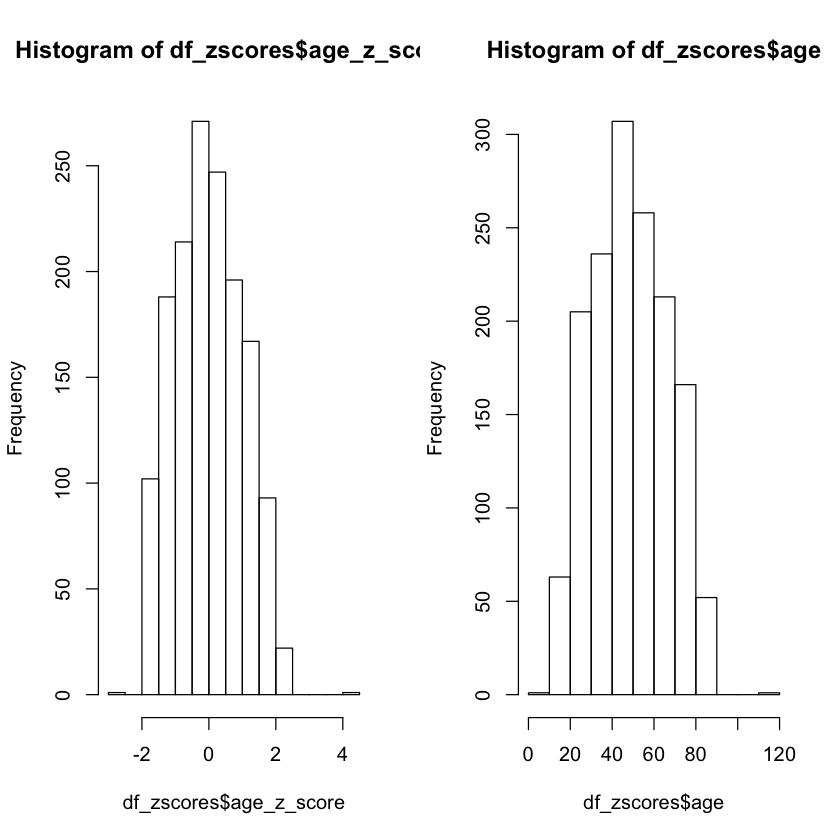

In [9]:
#Create histograms side by side
par(mfrow=c(1,2))

#Hist 1
hist(df_zscores$age_z_score)

#Hist 2
hist(df_zscores$age,
     #ylim = c(0,400),
     #xlim = c(0,100)
     )

# Filter outliers
- This is just for reference it does not need to be use in PS1

## F.1 Find outlier data: DPLYR--Filter

In [11]:
df %>% 
  filter(
    age>100
  )

state,vote,income,education,age,sex
SC,1,8,1,120,1


## F.2 Save new data frame WITHOUT outlier
- Note: the filter is inverse of the code above

In [12]:
df_no_outlier = df %>% 
  filter(
    age<100
  )

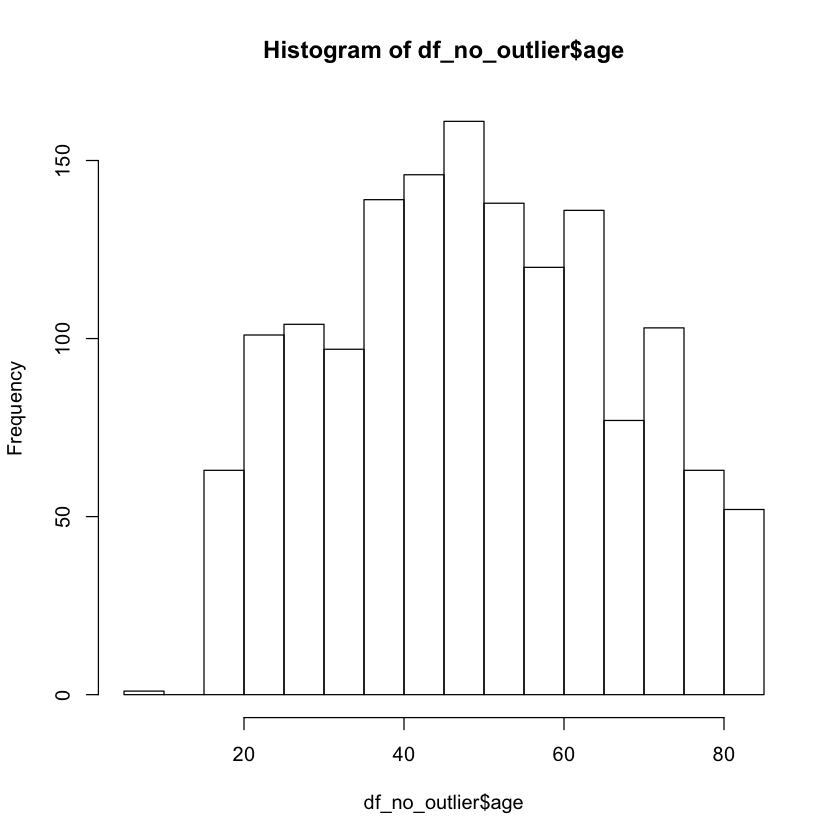

In [13]:
hist(df_no_outlier$age)

# IQR

## I.1 IQR function

In [14]:
IQR(df$age)

[1] 26

## I.2 Find quartile data only

In [16]:
summary(df$age)[2] #Grab second column
summary(df$age)[5] #Grab fifth column

1st Qu. 
     36 

3rd Qu. 
     62 

# Unique observations

- Shows unique observations

In [17]:
unique(df$vote)

[1] 1 0

In [18]:
unique(df$income)

[1]  9 11 12 16 10 14 17  8 15 13  5  6  7  4